ДЗ 1

Сначала расшифруем столбцы (СТОЛБЕЦ - ЧТО ЭТО - ЕДИИНИЦЫ)

Время - Начало 10-минутного интервала - время, чч:мм

Время поиска исполнителя - Сколько в среднем за интервал пассажир ждал, пока ему найдут водителя (от заказа до назначения водителя) - секунды

Средний сурж по поездкам - Среднее повышение цены в интервале - коэффициент

Доля свободных водителей - Какой % водителей на линии был в статусе ожидания заказа за интервал - %

Заказы - Число созданных заказов (заказ - это то, что создаёт пассажир, когда заказывает) за интервал - шт

Водителей на линии - Сколько водителей было на линии за интервал - шт

GMV - Общая выручка со всех поездок (order cost) за интервал - лок. валюта

Поездок за наличные - Какая доля поездок в интервале оплачена наличными - %

Среднее плановое время подачи (ETA)  исполнителя по поездкам - Предполагаемое время, за которое водитель доедет до точки А (до пассажира) - минуты

Фактическое ETA по поездкам (dropoff) - Реальное время, за которое водитель доехал до точки А (до пассажира) - минуты

Предложения - Число предложений (предложение - это заказ, который сервис предложил водителю), отправленных водителям за интервал - шт

CR - Доля заказов, которые в итоге выполнились - доля от 0 до 1

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('HW1SmallTown.csv')
df.head()

,Время,"Время поиска исполнителя, сек.",Средний сурж по поездкам,Доля свободных водителей,Заказы,"Водителей на линии, всего","GMV, лок. валюта","Поездок за наличные, %","Среднее плановое время подачи (ETA) исполнителя по поездкам, мин",Фактическое ETA по поездкам (dropoff),Предложения,CR
0,12:00:00 AM,22.61,1.17,16.350,16.0,26.3,280,14.29,5.86,5.960,16.0,0.8750
1,12:10:00 AM,26.69,1.43,20.000,15.0,25.5,226,27.27,5.90,5.900,12.0,0.7333
2,12:20:00 AM,14.45,1.24,45.820,12.0,27.5,183,12.50,3.98,3.300,11.0,0.6667
3,12:30:00 AM,26.59,1.00,39.220,13.0,23.2,273,18.18,5.12,5.700,15.0,0.8462
4,12:40:00 AM,44.82,1.14,19.048,10.0,18.9,96,40.00,7.52,7.028,7.0,0.5000


# **Задача 1:** Найти средний AR за день.

AR = Accepted / Requests - то есть Число принятых водителем предложений (соответственно заказов) / Число предложений которые ему отправили. То есть это коэффициент, сколько предложений, отправленных водителю, стали исполненными заказами.

CR - это коэффициент, сколько заказов, сделанных пользователями, стали исполненными заказами.

Соответсвенно знаем, сколько заказов было в итоге исполнено (то есть, сколько заказов принял водитель) - это CR * Заказы и поделим на все предложения.
Тогда AR = (CR * Заказы) / Предложения

In [49]:
orders = df['Заказы'].sum()
accepted = (df['Заказы'] * df['CR']).sum()
offers = df['Предложения'].sum()
AR = accepted / offers

print(f'AR (первый способ): {AR} ({AR * 100:.0f}%)')


AR (первый способ): 0.8080954913294799 (81%)


В целом, AR можно усреднить двумя способами:
1. Взвешенное среднее: Сумма заказов выполненных (то есть Заказы * CR) / Сумма предложений. Мне кажется, что так логичнее, потому что так мы учитываем число предложений за интервал. То есть в разные интервалы было разное число предложений, и если считать взвешенное среднее, то мы учтём, что в разные интервалы было разное число предложений. Поэтому я выбрала первый способ.
2. Простое среднее: Среднее по всем интервалам от (Заказы за интервал * CR за интервал / Предложения за интервал). Тут мы не учитываем, что условно ночью просто меньше заказов (и соответсвенно предложений), чем днём.

In [50]:
accepted_interval = df['Заказы'] * df['CR']
ar_interval = accepted_interval / df['Предложения']
ar = (ar_interval).mean()

print(f'AR (второй способ): {ar} ({ar * 100:.0f}%)')

AR (второй способ): 0.7738663293072955 (77%)


Разница небольшая, но так-то первый способ лучше: AR ночью может быть 1 и "тянуть" средний AR вверх, не учитывая, что ночью было в разы меньше заказов, чем днём, при этом днём будет маленький AR.

# **Задача 2:** Найти SH за день.


SH = Free + Driving + Waiting + Transporting.

То есть, это общее время, которое водитель провёл на линии.

У нас есть Водителей на линии - это количество водителей в каждый 10-минутный интервал.

Соответственно  SH за интервал - это Водителей на линии * 10 / 60. То есть просто перевели в часы из 10-минутных интервалов.

Тогда за день - это просто сумма SH за интервал по всем интервалам.


In [51]:
SH = (df['Водителей на линии, всего'] * 10 / 60).sum()
print('SH за день:', SH)

SH за день: 1445.8166666666666


# **Задача 3:** Найти средний ТPH за день.

TPH = Trips / SH

Trips - это число выполненных заказов. Мы знаем, сколько было всего заказов в интервале (столбец Заказы), а также знаем долю из этих заказов, которые в итоге были выполнены (CR). Тогда, чтобы найти число выполненных заказов, просто перемножим те два значения.

Trips за интервал = Заказы * CR

Тогда Trips - это сумма Trips за интервал по всем интервалам.

Ну а SH знаем из прошлого задания.

In [52]:
Trips = (df['Заказы'] * df['CR']).sum()
TPH = Trips / SH

print("Средний ТPH за день:", TPH)

Средний ТPH за день: 2.9007935077061413


# **Задача 4:** Найти средний MPH за день, в предположении что субсидий водителю нет, а комиссии составляют 22%.

MPH = Driver Net Income / SH

SH  знаем.

Посмотрим на Driver Net Income = Order Cost + Subventions - Commissions. Subventions = 0 по условию, а комиссия - 22%.

 Знаем GMV - это весь GMV за день, то есть сумма всех GMV за интервал по интервалам.

 Тогда Driver Net Income = GMV - 0.22 * GMV = 0.78 * GMV.


In [53]:
GMV = df['GMV, лок. валюта'].sum()
Driver_Net_Income = 0.78 * GMV
MPH = Driver_Net_Income / SH

print('Средний MPH за день:', MPH)

Средний MPH за день: 44.57083770418103


# **Задача 5:** Найти какую долю SH за день составляют водители в статусе “free”.

Число водителей в статусе free для каждого интервала (free_intervals) = Водителей на линии * Доля свободных водителей / 100. Так как Доля свободных водителей в процентах, то делим на 100.

Всего Число водителей в статусе free (free_drivers) - это сумма free_intervals по всем интервалам.

Тогда посчитаем, сколько часов суммарно за день водители были в статусе free (free) - это free_drivers * 10 / 60. Опять же переводим в часы.

Ну а SH мы знаем.

Итого Доля водителей в статусе free от SH за день = free / SH.

In [54]:
free_intervals = df['Водителей на линии, всего'] * df['Доля свободных водителей'] / 100
free_drivers = free_intervals.sum()
free = free_drivers * 10 / 60
free_share = free / SH

print(f'Доля водителей в статусе free от SH за день: {free_share} ({free_share*100:.0f}%)')

Доля водителей в статусе free от SH за день: 0.35895724884436714 (36%)


# **Задача 6:** Найти средний Efficiency за день в предположении что каждый водитель ждет пассажира по приезду в точку А ровно 40 секунд.

Efficiency = Tsansporing / SH.

Знаем, что Transporting = SH - Free - Driving - Waiting.

 Waiting = 40 * Поездки / 3600 (делим, чтобы перевести в часы), Free - знаем из задачи 5, а SH знаем из задачи 2, ну и Driving = сумма(Фактическое ETA по поездкам * Поездки / 60). Делим на 60, чтобы всё было в часах, а Поездки = Заказы * CR.

 SH опять же известно.

In [55]:
Trips = df['Заказы'] * df['CR']
Waiting = 40 * Trips.sum() / 3600
Driving = (Trips * df['Фактическое ETA по поездкам (dropoff)'] / 60
).sum()
Transporting = SH - free - Driving - Waiting
Efficiency = Transporting / SH

print(f'Efficiency: {Efficiency} ({Efficiency*100:.0f}%)')

Efficiency: 0.43871526923445797 (44%)


# **Задача** 7: Постройте scatterplot со средним суржом по оси x и долей свободных машин по оси y. На графике укажите корреляцию между этими двумя величинами.

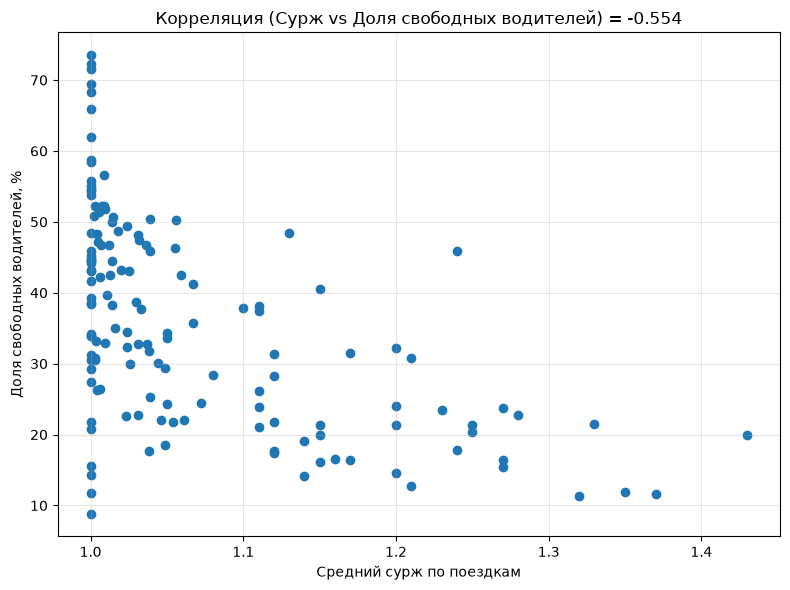

In [56]:
df_pure = df[['Средний сурж по поездкам', 'Доля свободных водителей']].dropna()
corr = df_pure['Средний сурж по поездкам'].corr(df_pure['Доля свободных водителей'])

plt.figure(figsize=(8, 6))
plt.scatter(df_pure['Средний сурж по поездкам'], df_pure['Доля свободных водителей'])

plt.xlabel('Средний сурж по поездкам')
plt.ylabel('Доля свободных водителей, %')
plt.title(f'Корреляция (Сурж vs Доля свободных водителей) = {corr:.3f}')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Как видим, корелляция отрицательная, что в целом логично, так как чем меньше свободных водилетей, тем больше будет повышение цены (сурж) из-за дефицита.

# **Задача 8:** Найти какую долю за день составляют заказы сделанные при минимальном сурже.

Находим, какой сурж является минимальным.

Затем ищем число всех заказов, выполненных с таким суржем - это будет сумма Trips (= Заказы * CR) по всем нужных интервалам (по интервалам с минимальным суржем).

Ну и далее просто делим на сумму всех Trips по всем интервалам.

In [57]:
min_surge = df['Средний сурж по поездкам'].min()
orders_min_surge = df.loc[df['Средний сурж по поездкам'] == min_surge, 'Заказы'].sum()
orders_total = df['Заказы'].sum()
surge_share = orders_min_surge / orders_total

print('Минимальный сурж:', min_surge)
print(f'Доля заказов сделанных при минимальном сурже за день: {surge_share} ({surge_share*100:.0f}%)')

Минимальный сурж: 1.0
Доля заказов сделанных при минимальном сурже за день: 0.11561561561561562 (12%)


# **Задача 9:** Постройте scatterplot с количеством свободных машин по оси x и временем поиска исполнителя по оси y.

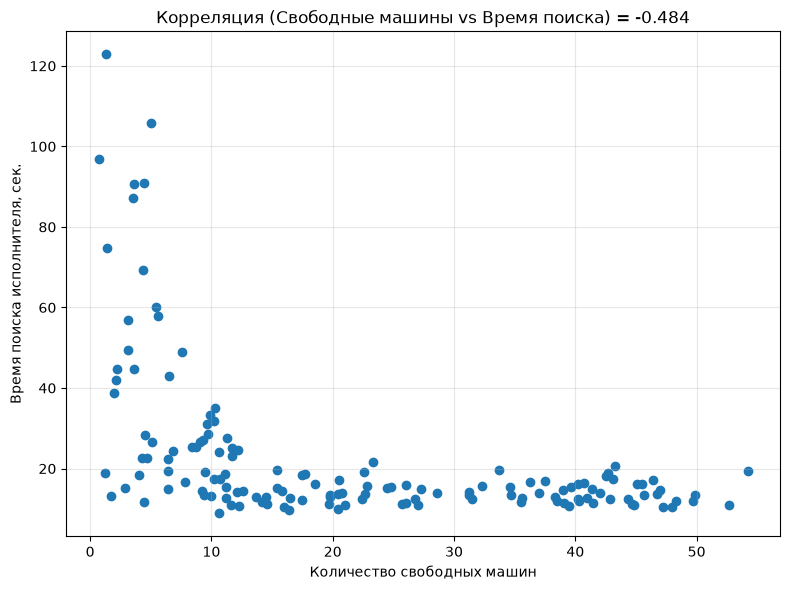

In [58]:
df['Свободные машины'] = df['Водителей на линии, всего'] * df['Доля свободных водителей'] / 100
df_pure_1 = df[['Свободные машины', 'Время поиска исполнителя, сек.']].dropna()
corr = df_pure_1['Свободные машины'].corr(df_pure_1['Время поиска исполнителя, сек.'])

plt.figure(figsize=(8, 6))
plt.scatter(df_pure_1['Свободные машины'], df_pure_1['Время поиска исполнителя, сек.'])

plt.xlabel('Количество свободных машин')
plt.ylabel('Время поиска исполнителя, сек.')
plt.title(f'Корреляция (Свободные машины vs Время поиска) = {corr:.3f}')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Видим, что корреляция отрицательная. Что тоже логично, так как чем больше свободых водителей, тем быстрее находится машина для заказчика, то есть меньше время поиска. Ну и наоборот, чем меньше свободных исполнителей, тем дольше свободный исполнитель будет искаться.

# **Задача 10:** Основываясь на вычислениях в предыдущих задачах (и каких-либо дополнительных вычислениях которые вы можете провести) дайте характеристику работе сервиса такси в этом городе, а также рекомендации по возможным изменениям.

Пройдёмся по каждому заданию и поймём, что говорит нам каждый результат:

1. 81% предложений водители принимают. Довольно высокий показатель, но на самом деле, могло быть и лучше. Аж пятую часть предложений водители отклоняют. Но учитывая, что одно предложение рассылается нескольким водителям, то не всё так плохо, то есть то, что водитель "отклонил предложение" часто связано с тем, что это предложение просто уже принял другой исполнитель.
2. 1446 часов водители проводят на линии. В целом, результат неплохой, но далее мы ещё это обсудим.
3. 2.9 поездки в час. Если действие происходит в маленьком городе, то это может быть неплохо, но так число не впечатляет.
4. 44.57 ед/час - мы не знаем валюты, так что нельзя что-то тут сказать.
5. 36% времени водители free - то есть простаивают. Это очень много для такси.
6. 44% времени водители везут пассажиров - меньше  половины времени. Это неэффективно.
7. -0.55 кореляция между суржем и свободными машинами - умеренная, думаю, что это неплохо, то есть корреляция есть, но при этом не слишком сильная, то есть в случаях, когда водителей нет, цены не подлетают вверх до бесконечности.
8. 12% - доля заказов при сурже 1.0, то есть почти все заказы с суржем. Стоит узнать, какой сурж средний и какой самый частый, потому что возможно большинство заказов "с суржем" - это заказы с суржем 1.1, тогда это нестрашно. Если же наценка стабильно высокая, то неудивительно, что водители всё время простаивают.
9. -0.48 - корреляция между свободными машинами и временем поиска, я бы сказала, что связь умеренная. Но так-то неидеальна, то есть время поиска сильно зависит от других факторов (пробки, алгоритмы), над которыми точно стоит поработать

Для начала скажу, что время, когда водители не работают составляет треть - почти столько же, сколько они проводят, везя пассажира. Это очень нехороший результат. При этом аж 1446 часов водители на линии, но целых 36 процентов из них исполнители просто простаивают. Можно попробовать уменьшить количество водителей, но корреляция между свободными машинами и временем поиска немаленькая (-0.48), то есть мы можем сильно увеличить время поиска машины для пассажира.

Теперь поговорим о сурже: корреляция между суржем и свободными водителями -0.55 - не очень много, но и немало, поэтому мы также не можем просто оставить поменьше водителей, ведь тогда сурж на поездках будет очень высоким, и цены будут большие, соответсвенно никто не захочет у нас заказывать такси. При такой корреляции у нас ещё и аж 88% поездок с суржем (>1.0). То есть, это очень много. Но посмотрим, какой вообще средний и самый частый суржи:

In [59]:
print(f"Средний сурж по всем интервалам: {df['Средний сурж по поездкам'].mean()}")
print(f"Самые частые суржи по всем интервалам: {df['Средний сурж по поездкам'].value_counts().head()}")

Средний сурж по всем интервалам: 1.0687622377622377
Самые частые суржи по всем интервалам: Средний сурж по поездкам
1.00    40
1.12     5
1.11     5
1.15     4
1.20     4
Name: count, dtype: int64


Как видим, боятся не стоило того, что почти на всех поездках есть сурж, ведь он маленький в большинстве своём, так что результат приемлемый.

Теперь поговорим о заказах, сделанных заказчиками, которые реально дошли до исполнения:

In [60]:
print(f"Доля заказов, которые не выполнились: {(1 - df['CR'].mean())*100:.0f}%")

Доля заказов, которые не выполнились: 14%


Как видим, целых 14% заказов не дошли до исполнения. Тяжело сказать, с чем это связано: возможно и с тем, что водители часто не принимают предложения (AR = 81%, что не так много, но учитывая, что одно и то же предложение рассылается нескольким водителям, то не так страшно), и с тем, что алгоритмы рассылания предложений работают не так хорошо.

В завершении посмотрим на пиковые часы, и сколько процентов SH в эти часы составляет от общего SH:

In [61]:
df['SH_interval'] = df['Водителей на линии, всего'] * 10 / 60

peak = df.nlargest(20, 'Заказы')
print(peak[['Время', 'Заказы', 'Водителей на линии, всего', 'SH_interval']])

SH_peak = peak['SH_interval'].sum()
SH_total = df['SH_interval'].sum()

orders_peak = peak['Заказы'].sum()
orders_total = df['Заказы'].sum()

SH_share = SH_peak / SH_total
orders_share = orders_peak / orders_total

print(f"Доля SH в пик: {SH_share:.2%}")
print(f"Доля заказов в пик: {orders_share:.2%}")
print(f"Соотношение доля SH / доля заказов: {SH_share / orders_share:.2f}")

          Время  Заказы  Водителей на линии, всего  SH_interval
45   7:30:00 AM    81.0                       91.2    15.200000
48   8:00:00 AM    80.0                      110.0    18.333333
50   8:20:00 AM    78.0                      105.9    17.650000
51   8:30:00 AM    77.0                      103.8    17.300000
52   8:40:00 AM    77.0                      106.2    17.700000
100  4:40:00 PM    69.0                       97.5    16.250000
47   7:50:00 AM    68.0                      110.1    18.350000
99   4:30:00 PM    67.0                       86.9    14.483333
103  5:10:00 PM    63.0                       93.1    15.516667
49   8:10:00 AM    61.0                      104.2    17.366667
44   7:20:00 AM    60.0                       73.2    12.200000
58   9:40:00 AM    60.0                       98.2    16.366667
101  4:50:00 PM    59.0                      102.7    17.116667
106  5:40:00 PM    59.0                       81.5    13.583333
85   2:10:00 PM    57.0                 

Как видим, разница не прям большая. То есть в целом, во время пиков (утренний: в 7-9 утра и вечерний: в 4-5 вечера) водителей действительно много, почти хватает (прям немного меньше нужного). 
Но большой процент простоев говорит о том, что в остальное время, когда заказов не так много, водители скапливаются на линии, не смотря на то что заказов мало.

В общем и целом, вердикт такой, что нужно получше перераспределять водителей на линии по дню (чтобы они не простаивали, когда заказов мало, и не было нехватки водителей в пиковые часы). Ну и так как всё же в пиковые часы водителей почти что хватает (не хватает, но не катастрофично - 0.8 соотношение), то можно и сократить немного водителей, при этом сделав нормальное распределение водителей по часам. 